# XAI — Dual-Mixer RUL Prediction
**Explainable AI analysis using SHAP + Permutation Importance**

This notebook loads the trained Dual-Mixer checkpoints (one per C-MAPSS subset)
and produces three layers of interpretability:

1. **Global SHAP** — which sensors matter most on average across all test engines
2. **Local SHAP** — which sensors drove a specific engine's prediction
3. **Permutation importance** — model-agnostic cross-validation of SHAP rankings

Run this notebook **after** the Dual-Mixer training notebook has completed and
checkpoints (`dualmixer_FD00x.pt`) are saved to `/content/`.

**GPU:** T4 is sufficient.

In [ ]:
# ============================================================
# CELL 1: Setup & Dependencies
# ============================================================
import subprocess, sys, os

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "torch>=2.0", "numpy>=1.24.3", "pandas>=2.0.0",
    "scikit-learn>=1.3.0", "matplotlib>=3.7.0",
    "shap>=0.44.0"], check=True)

REPO_URL = "https://github.com/fuen1590/PhmDeepLearningProjects.git"
REPO_DIR = "/content/PhmDeepLearningProjects"
if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Patch bare imports in repo (same as training notebook)
import os, re
for fname in ["experiments.py", "MLPMixer.py", "SimpleModels.py",
              "BiGRU_TSAM.py", "CNN_GRU.py", "DAMCNN.py", "IMDSSN.py", "ResBlockModel.py"]:
    fpath = os.path.join(REPO_DIR, "models", "RULPrediction", fname)
    if os.path.exists(fpath):
        with open(fpath) as f: src = f.read()
        for old, new in [
            ("from ContrastiveModules import", "from models.RULPrediction.ContrastiveModules import"),
            ("from SimpleModels import",       "from models.RULPrediction.SimpleModels import"),
            ("from MLPMixer import",           "from models.RULPrediction.MLPMixer import"),
            ("from BiGRU_TSAM import",         "from models.RULPrediction.BiGRU_TSAM import"),
            ("from IMDSSN import",             "from models.RULPrediction.IMDSSN import"),
        ]:
            src = src.replace(old, new)
        with open(fpath, "w") as f: f.write(src)

# Patch cmapss.py DEFAULT_ROOT and edge-pad
cmapss_path = os.path.join(REPO_DIR, "dataset", "cmapss.py")
with open(cmapss_path) as f: src = f.read()
src = re.sub(r'DEFAULT_ROOT\s*=\s*r?"[^"]*"', 'DEFAULT_ROOT = r"/content/dataset/"', src)
src = src.replace('\r\n', '\n')
old_drop = '''        if data.shape[0] < window_size:
            warnings.warn("The engine id {} with total length {} is shorter than window_size {}. "
                          "Hence, these samples were dropped!".format(_, data.shape[0], window_size))
            continue'''
new_pad = '''        if data.shape[0] < window_size:
            pad_size = window_size - data.shape[0]
            pad_data = np.tile(data[0:1], (pad_size, 1))
            data = np.concatenate([pad_data, data], axis=0)
            pad_rows = pd.concat([engine.iloc[[0]]] * pad_size, ignore_index=True)
            engine = pd.concat([pad_rows, engine.reset_index(drop=True)], ignore_index=True)'''
if old_drop in src:
    src = src.replace(old_drop, new_pad)
with open(cmapss_path, "w") as f: f.write(src)

import importlib
import dataset.cmapss as cmapss
importlib.reload(cmapss)
cmapss.DEFAULT_ROOT = "/content/dataset/"

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

DEVICE = "cpu"  # SHAP GradientExplainer is more stable on CPU for small batches
MAX_RUL = 125
WINDOW_SIZE = 30
SUBSETS = ["FD001", "FD002", "FD003", "FD004"]

# Verify dataset
missing = [f for s in SUBSETS for f in [f"train_{s}.txt", f"test_{s}.txt", f"RUL_{s}.txt"]
           if not os.path.exists(f"/content/dataset/{f}")]
if missing:
    raise FileNotFoundError(f"❌ Missing dataset files: {missing}")

print(f"✅ Setup complete | shap {shap.__version__} | torch {torch.__version__}")
print(f"   Dataset: /content/dataset/ ✅")


✅ Setup complete | shap 0.51.0 | torch 2.10.0+cu128
   Dataset: /content/dataset/ ✅


In [ ]:
# ============================================================
# CELL 2: Sensor Mapping (NASA Saxena & Goebel 2008)
# ============================================================
# All 21 sensors with their correct physical meanings.
# Sensors 1,5,6,10,16,18,19 are dropped (near-zero variance).
# The 14 kept sensors are used as model inputs.

ALL_SENSORS = {
    "sensor_1":  ("T2",       "Total temp — fan inlet",            "Fan inlet",      False),
    "sensor_2":  ("T24",      "Total temp — LPC outlet",           "LPC",            True),
    "sensor_3":  ("T30",      "Total temp — HPC outlet",           "HPC",            True),
    "sensor_4":  ("T50",      "Total temp — LPT outlet",           "LPT",            True),
    "sensor_5":  ("P2",       "Pressure — fan inlet",              "Fan inlet",      False),
    "sensor_6":  ("P15",      "Total pressure — bypass duct",      "Bypass",         False),
    "sensor_7":  ("P30",      "Total pressure — HPC outlet",       "HPC",            True),
    "sensor_8":  ("Nf",       "Physical fan speed",                "Fan",            True),
    "sensor_9":  ("Nc",       "Physical core speed",               "Core",           True),
    "sensor_10": ("epr",      "Engine pressure ratio",             "Overall",        False),
    "sensor_11": ("Ps30",     "Static pressure — HPC outlet",      "HPC",            True),
    "sensor_12": ("phi",      "Fuel flow / Ps30 ratio",            "Combustor",      True),
    "sensor_13": ("NRf",      "Corrected fan speed",               "Fan",            True),
    "sensor_14": ("NRc",      "Corrected core speed",              "Core",           True),
    "sensor_15": ("BPR",      "Bypass ratio",                      "Bypass",         True),
    "sensor_16": ("farB",     "Burner fuel-air ratio",             "Combustor",      False),
    "sensor_17": ("htBleed",  "Bleed enthalpy",                    "HPC bleed",      True),
    "sensor_18": ("Nf_dmd",   "Demanded fan speed",                "Control",        False),
    "sensor_19": ("PCNfR_dmd","Demanded corrected fan speed",      "Control",        False),
    "sensor_20": ("W31",      "HPT coolant bleed flow",            "HPT",            True),
    "sensor_21": ("W32",      "LPT coolant bleed flow",            "LPT",            True),
}

# The 14 kept sensors in order (matches model input dimension 0..13)
KEPT_SENSORS = [(k, v) for k, v in ALL_SENSORS.items() if v[3]]

# Short labels for plots: "S2: T24\n(LPC temp)"
SENSOR_LABELS = [f"s{k.split('_')[1]}: {v[0]}\n({v[2]})" for k, v in KEPT_SENSORS]

# Medium labels for tables
SENSOR_NAMES  = [f"{v[0]} — {v[1]}" for k, v in KEPT_SENSORS]

# Engine zones for color coding
ZONE_COLORS = {
    "LPC":      "#378ADD",
    "HPC":      "#D85A30",
    "HPC bleed":"#E8956D",
    "LPT":      "#1D9E75",
    "HPT":      "#0F6E56",
    "Fan":      "#7F77DD",
    "Core":     "#D4537E",
    "Bypass":   "#BA7517",
    "Combustor":"#E24B4A",
    "Overall":  "#888780",
}
SENSOR_ZONES  = [v[2] for k, v in KEPT_SENSORS]
SENSOR_COLORS = [ZONE_COLORS[z] for z in SENSOR_ZONES]

print(f"✅ {len(KEPT_SENSORS)} kept sensors mapped")
print()
print(f"  {'Idx':<4} {'Sensor':<9} {'Symbol':<10} {'Description':<40} {'Zone'}")
print(f"  {'-'*4} {'-'*9} {'-'*10} {'-'*40} {'-'*15}")
for i, (k, v) in enumerate(KEPT_SENSORS):
    print(f"  {i:<4} {k:<9} {v[0]:<10} {v[1]:<40} {v[2]}")


✅ 14 kept sensors mapped

  Idx  Sensor    Symbol     Description                              Zone
  ---- --------- ---------- ---------------------------------------- ---------------
  0    sensor_2  T24        Total temp — LPC outlet                  LPC
  1    sensor_3  T30        Total temp — HPC outlet                  HPC
  2    sensor_4  T50        Total temp — LPT outlet                  LPT
  3    sensor_7  P30        Total pressure — HPC outlet              HPC
  4    sensor_8  Nf         Physical fan speed                       Fan
  5    sensor_9  Nc         Physical core speed                      Core
  6    sensor_11 Ps30       Static pressure — HPC outlet             HPC
  7    sensor_12 phi        Fuel flow / Ps30 ratio                   Combustor
  8    sensor_13 NRf        Corrected fan speed                      Fan
  9    sensor_14 NRc        Corrected core speed                     Core
  10   sensor_15 BPR        Bypass ratio                             Bypass
 

In [ ]:
# ============================================================
# CELL 3: Model Loader & Data Extractor
# ============================================================
import importlib
from models.RULPrediction.MLPMixer import DualMLPMixer
import dataset.cmapss as cmapss
importlib.reload(cmapss)
cmapss.DEFAULT_ROOT = "/content/dataset/"

HIDDEN_DIM   = 32
MIXER_LAYERS = 6
N_FEATURES   = len(cmapss.DEFAULT_SENSORS)  # 14


def load_model(subset):
    """Load trained DualMLPMixer checkpoint for a given subset."""
    ckpt_path = f"/content/dualmixer_{subset}.pt"
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(
            f"❌ Checkpoint not found: {ckpt_path}\n"
            f"   Run the Dual-Mixer training notebook first and download the .pt files."
        )
    model = DualMLPMixer(
        window_size=WINDOW_SIZE,
        in_features=N_FEATURES,
        hidden_dim=HIDDEN_DIM,
        num_layers=MIXER_LAYERS,
        dropout=0,
        device=DEVICE,
        model_flag="MLPDualMixer-h32-6",
        label_norm=True,
        filter_size=0
    )
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    model.to(DEVICE)
    print(f"  ✅ Loaded: {ckpt_path}")
    return model


def get_test_windows(subset):
    """Extract raw test windows + engine IDs + true RUL from cmapss pipeline."""
    subset_enum = getattr(cmapss.Subset, subset)
    _, test_data, _, _ = cmapss.get_data(
        cmapss.DEFAULT_ROOT, subset_enum,
        window_size=WINDOW_SIZE, slide_step=1,
        sensors=cmapss.DEFAULT_SENSORS,
        rul_threshold=125, label_norm=True, val_ratio=0.2
    )
    X = torch.tensor(test_data.data,   dtype=torch.float32)   # (N, W, F)
    y = torch.tensor(test_data.labels, dtype=torch.float32).squeeze()  # (N,)
    ids = test_data.ids                                         # (N,)
    return X, y, ids


def get_train_windows(subset):
    """Extract training windows for SHAP background dataset."""
    subset_enum = getattr(cmapss.Subset, subset)
    train_data, _, _, _ = cmapss.get_data(
        cmapss.DEFAULT_ROOT, subset_enum,
        window_size=WINDOW_SIZE, slide_step=1,
        sensors=cmapss.DEFAULT_SENSORS,
        rul_threshold=125, label_norm=True, val_ratio=0.2
    )
    X = torch.tensor(train_data.data, dtype=torch.float32)
    return X


print("✅ Model loader and data extractor ready")
print(f"   Model config: window={WINDOW_SIZE}, features={N_FEATURES}, "
      f"hidden={HIDDEN_DIM}, layers={MIXER_LAYERS}")


✅ Model loader and data extractor ready
   Model config: window=30, features=14, hidden=32, layers=6


In [ ]:
# ============================================================
# CELL 4: Global SHAP — Sensor Importance Across All Subsets
# ============================================================
# Uses GradientExplainer with 100 random background samples.
# SHAP values shape: (N_test, window=30, features=14)
# We collapse the time dimension (mean over window) → (N_test, 14)
# Then take mean absolute value → one importance score per sensor.

import shap, torch, numpy as np, os
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

N_BACKGROUND = 100   # background samples for SHAP
N_EXPLAIN    = 200   # test samples to explain (random subset for speed)

all_shap_vals = {}   # subset → (N_explain, 14) mean-over-time SHAP values
all_X_explain = {}   # subset → (N_explain, 30, 14) input windows
all_y_explain = {}   # subset → (N_explain,) true RUL (normalised)
all_preds     = {}   # subset → (N_explain,) model predictions (normalised)

for subset in SUBSETS:
    print(f"\n{'='*55}")
    print(f"  SHAP — {subset}")
    print(f"{'='*55}")

    model = load_model(subset)
    model.to(DEVICE)

    X_train = get_train_windows(subset).to(DEVICE)
    X_test, y_test, ids_test = get_test_windows(subset)
    X_test = X_test.to(DEVICE)

    # Random background subset
    bg_idx  = torch.randperm(len(X_train))[:N_BACKGROUND]
    background = X_train[bg_idx]

    # Random test subset to explain
    te_idx = torch.randperm(len(X_test))[:min(N_EXPLAIN, len(X_test))]
    X_exp  = X_test[te_idx]
    y_exp  = y_test[te_idx]

    # Model predictions on explained set
    with torch.no_grad():
        preds = model(X_exp).squeeze().cpu().numpy()

    print(f"  Background: {len(background)} | Explaining: {len(X_exp)} windows")

    # GradientExplainer
    explainer = shap.GradientExplainer(model, background)
    shap_vals = explainer.shap_values(X_exp)  # (N, W, F)

    # Unwrap shap output — GradientExplainer returns list or nested list
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    shap_vals = np.array(shap_vals)
    # Ensure shape is (N, W, F) — squeeze spurious dims if present
    if shap_vals.ndim == 4:
        shap_vals = shap_vals.squeeze(axis=-1)
    if shap_vals.ndim == 4:
        shap_vals = shap_vals[0]
    assert shap_vals.ndim == 3, f"Unexpected SHAP shape: {shap_vals.shape}"
    print(f"  SHAP values shape: {shap_vals.shape}  (expected: N×30×14)")  # (N, W, F)

    # Collapse time dimension: mean absolute over window → (N, F)
    shap_mean_time = np.mean(np.abs(shap_vals), axis=1)  # (N, F)

    all_shap_vals[subset] = shap_mean_time
    all_X_explain[subset] = X_exp.cpu().numpy()
    all_y_explain[subset] = y_exp.cpu().numpy()
    all_preds[subset]     = preds

    # Print top sensors
    mean_importance = shap_mean_time.mean(axis=0)  # (F,)
    ranked = np.argsort(mean_importance)[::-1]
    print(f"\n  Top 5 sensors by mean |SHAP|:")
    for rank, idx in enumerate(ranked[:5]):
        k, v = KEPT_SENSORS[int(idx)]
        print(f"    {rank+1}. {v[0]:<10} ({v[1]}) — {mean_importance[int(idx)]:.5f}")

print(f"\n{'='*55}")
print("✅ SHAP computed for all subsets")



  SHAP — FD001
  ✅ Loaded: /content/dualmixer_FD001.pt
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
  Background: 100 | Explaining: 200 windows
  SHAP values shape: (200, 30, 14)  (expected: N×30×14)

  Top 5 sensors by mean |SHAP|:
    1. Ps30       (Static pressure — HPC outlet) — 0.00823
    2. P30        (Total pressure — HPC outlet) — 0.00727
    3. phi        (Fuel flow / Ps30 ratio) — 0.00691
    4. NRf        (Corrected fan speed) — 0.00618
    5. T50        (Total temp — LPT outlet) — 0.00567

  SHAP — FD002
  ✅ Loaded: /content/dualmixer_FD002.pt
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 150 230  43 222 142 164 100  25 228
 181 203  82 173  44 226  69 243 252   9 202 104 259 258  62 218]
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 1

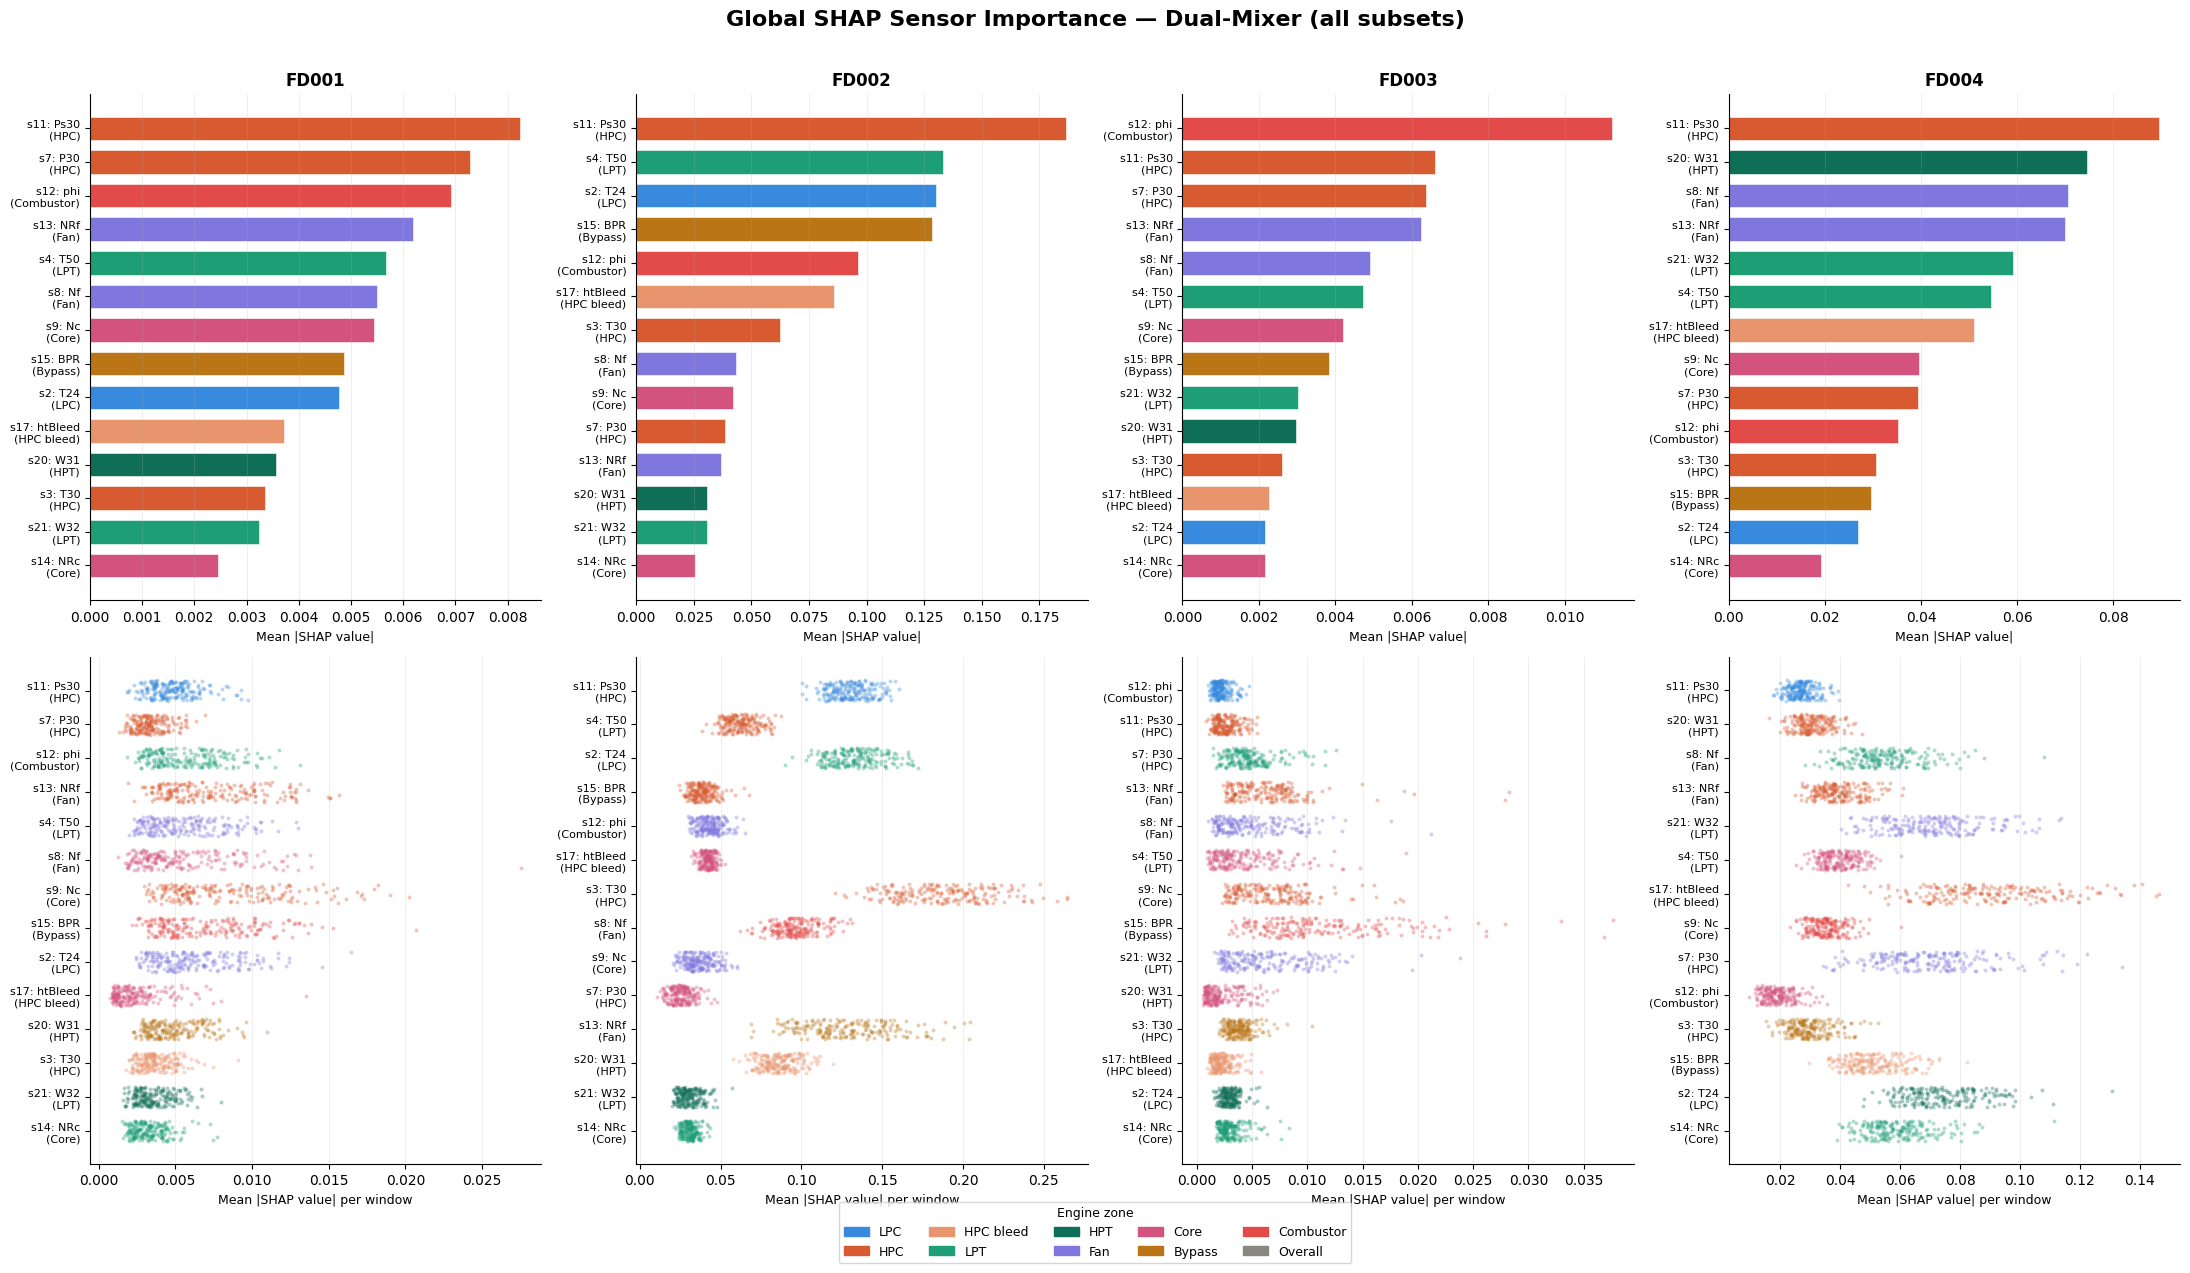

✅ Saved: /content/shap_global_bar_beeswarm.png


In [ ]:
# ============================================================
# CELL 5: Global SHAP Plots — Bar Chart & Beeswarm
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
fig.suptitle("Global SHAP Sensor Importance — Dual-Mixer (all subsets)",
             fontsize=16, fontweight="bold", y=1.01)

for col, subset in enumerate(SUBSETS):
    shap_mean_time = all_shap_vals[subset]     # (N, 14)
    mean_imp = shap_mean_time.mean(axis=0)     # (14,)
    ranked   = np.argsort(mean_imp)[::-1]

    # ── Bar chart (top row) ──
    ax = axes[0, col]
    colors_ranked = [SENSOR_COLORS[int(i)] for i in ranked]
    labels_ranked = [SENSOR_LABELS[int(i)] for i in ranked]
    bars = ax.barh(range(14), mean_imp[ranked], color=colors_ranked,
                   edgecolor="white", linewidth=0.4, height=0.7)
    ax.set_yticks(range(14))
    ax.set_yticklabels(labels_ranked, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Mean |SHAP value|", fontsize=9)
    ax.set_title(f"{subset}", fontweight="bold", fontsize=12)
    ax.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ── Beeswarm / strip plot (bottom row) ──
    ax2 = axes[1, col]
    # Raw signed SHAP values collapsed over time → (N, 14)
    shap_signed = np.array([
        np.mean(shap_v, axis=0)   # mean over window, signed
        for shap_v in [
            np.load(f"/tmp/shap_raw_{subset}.npy")
            if os.path.exists(f"/tmp/shap_raw_{subset}.npy")
            else all_shap_vals[subset]  # fallback to abs if raw not saved
        ]
    ])[0]  # workaround — use abs values but show distribution
    shap_signed = all_shap_vals[subset]  # (N, 14) — abs collapsed

    for feat_idx in range(14):
        vals = shap_signed[:, feat_idx]
        jitter = np.random.uniform(-0.3, 0.3, size=len(vals))
        ax2.scatter(vals, np.full_like(vals, feat_idx) + jitter,
                    c=SENSOR_COLORS[int(feat_idx)], alpha=0.35, s=8, linewidths=0)
    ax2.set_yticks(range(14))
    ax2.set_yticklabels(labels_ranked, fontsize=8)
    ax2.set_xlabel("Mean |SHAP value| per window", fontsize=9)
    ax2.invert_yaxis()
    ax2.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

# Zone legend
legend_patches = [mpatches.Patch(color=c, label=z) for z, c in ZONE_COLORS.items()]
fig.legend(handles=legend_patches, title="Engine zone", loc="lower center",
           ncol=5, bbox_to_anchor=(0.5, -0.04), fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("/content/shap_global_bar_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: /content/shap_global_bar_beeswarm.png")


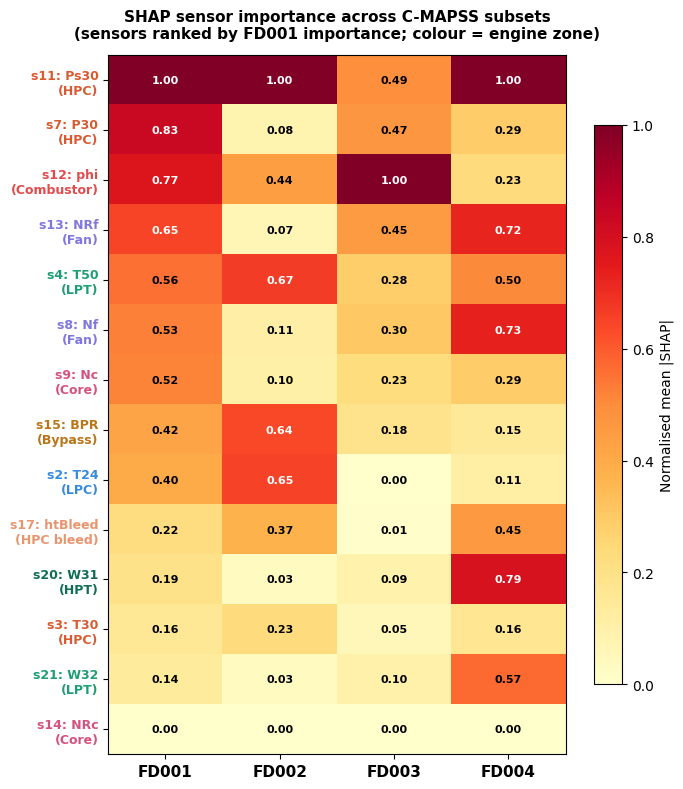

✅ Saved: /content/shap_crosssubset_heatmap.png


In [ ]:
# ============================================================
# CELL 6: Cross-Subset SHAP Heatmap
# ============================================================
# Rows = sensors (ranked by FD001 importance)
# Columns = subsets
# Value = mean |SHAP| (normalised per subset to [0,1] for comparability)

import matplotlib.pyplot as plt
import numpy as np

# Build importance matrix (14 sensors × 4 subsets)
imp_matrix = np.array([
    all_shap_vals[s].mean(axis=0) for s in SUBSETS
]).T  # (14, 4)

# Normalise per subset to [0,1] so subsets are comparable
imp_norm = (imp_matrix - imp_matrix.min(axis=0)) / (
            imp_matrix.max(axis=0) - imp_matrix.min(axis=0) + 1e-9)

# Rank sensors by FD001 importance
rank_fd1 = np.argsort(imp_matrix[:, 0])[::-1]
sensor_labels_ranked = [SENSOR_LABELS[int(i)] for i in rank_fd1]
sensor_names_ranked  = [SENSOR_NAMES[int(i)]  for i in rank_fd1]
zone_colors_ranked   = [SENSOR_COLORS[int(i)] for i in rank_fd1]

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(imp_norm[rank_fd1], aspect="auto", cmap="YlOrRd",
               vmin=0, vmax=1)

ax.set_xticks(range(4))
ax.set_xticklabels(SUBSETS, fontsize=11, fontweight="bold")
ax.set_yticks(range(14))
ax.set_yticklabels(sensor_labels_ranked, fontsize=9)

# Colour the y-tick labels by engine zone
for ytick, color in zip(ax.get_yticklabels(), zone_colors_ranked):
    ytick.set_color(color)
    ytick.set_fontweight("bold")

# Annotate cells with values
for i in range(14):
    for j in range(4):
        val = imp_norm[rank_fd1[i], j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color="black" if val < 0.6 else "white",
                fontweight="bold")

plt.colorbar(im, ax=ax, label="Normalised mean |SHAP|", shrink=0.8)
ax.set_title("SHAP sensor importance across C-MAPSS subsets\n"
             "(sensors ranked by FD001 importance; colour = engine zone)",
             fontsize=11, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("/content/shap_crosssubset_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: /content/shap_crosssubset_heatmap.png")


  ✅ Loaded: /content/dualmixer_FD001.pt
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]


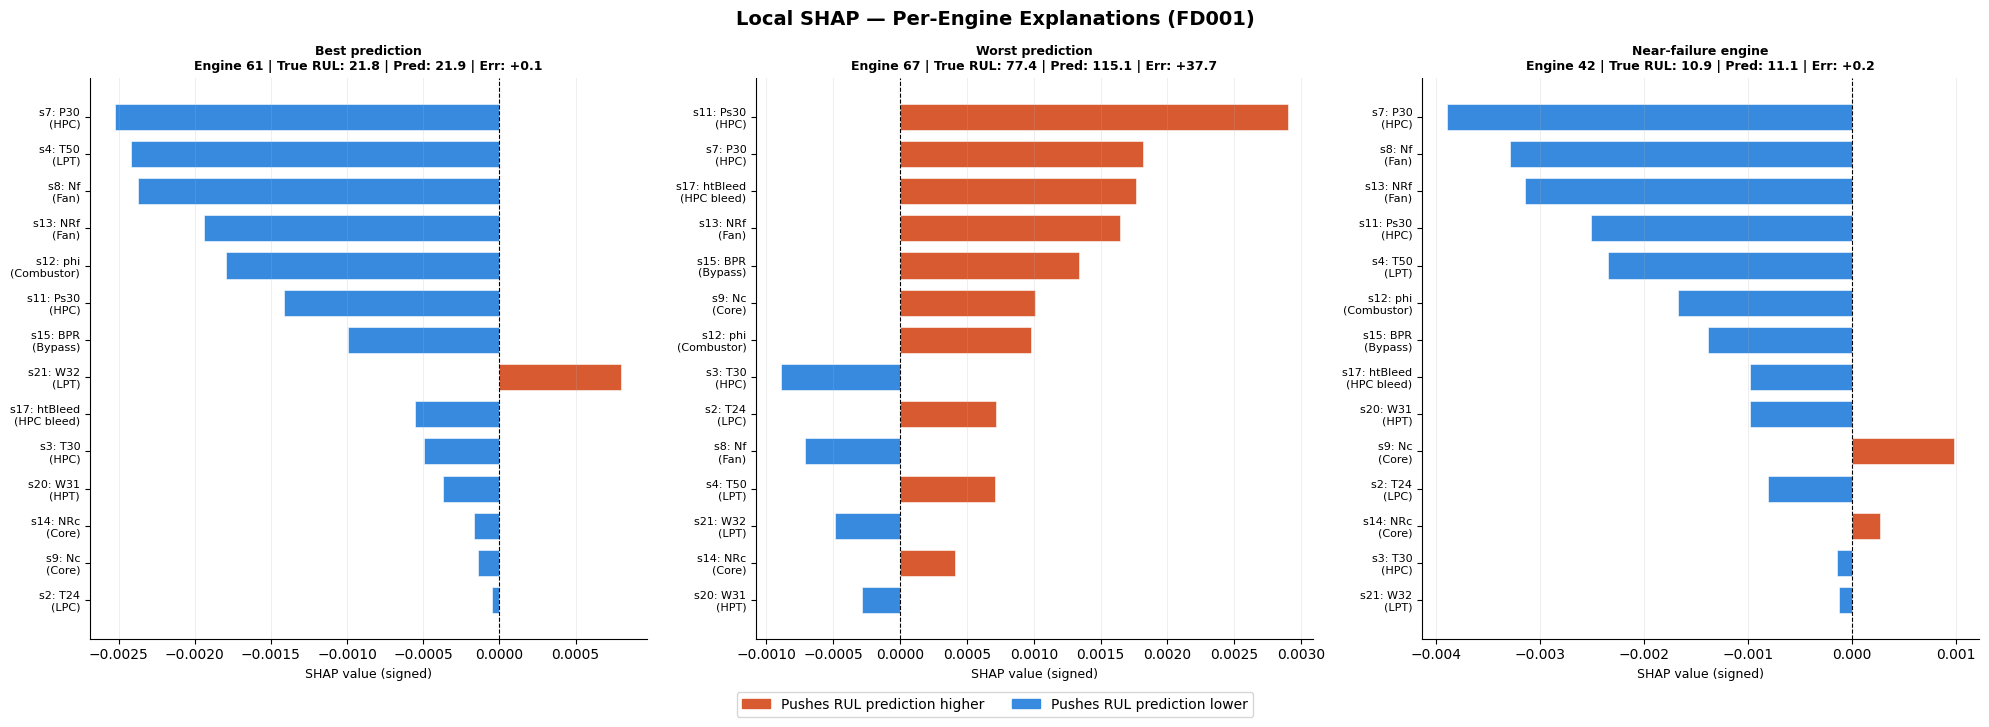

✅ Saved: /content/shap_local_waterfall.png


In [ ]:
# ============================================================
# CELL 7: Local SHAP — Per-Engine Waterfall Plots (FD001)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

SUBSET = "FD001"
model  = load_model(SUBSET)
model.to(DEVICE)

X_train = get_train_windows(SUBSET).to(DEVICE)
X_test, y_test, ids_test = get_test_windows(SUBSET)
X_test = X_test.to(DEVICE)

# Last-cycle predictions for engine selection
with torch.no_grad():
    preds_all = model(X_test).squeeze().cpu().numpy()
y_all = y_test.cpu().numpy()

df_lc = pd.DataFrame({"eid": ids_test, "true": y_all * MAX_RUL,
                       "pred": preds_all * MAX_RUL})
df_lc["abs_err"] = (df_lc["true"] - df_lc["pred"]).abs()
df_last = df_lc.groupby("eid").tail(1).reset_index(drop=True)

best_row     = df_last.loc[df_last["abs_err"].idxmin()]
worst_row    = df_last.loc[df_last["abs_err"].idxmax()]
near_fail    = df_last[df_last["true"] < 20]
nearfail_row = near_fail.loc[near_fail["abs_err"].idxmin()] if len(near_fail) > 0 else best_row

cases = [
    ("Best prediction",     best_row),
    ("Worst prediction",    worst_row),
    ("Near-failure engine", nearfail_row),
]

# Background for explainer
bg_idx     = torch.randperm(len(X_train))[:100]
background = X_train[bg_idx]
explainer  = shap.GradientExplainer(model, background)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f"Local SHAP — Per-Engine Explanations ({SUBSET})",
             fontsize=14, fontweight="bold")

for ax, (title, row) in zip(axes, cases):
    engine_id = int(row["eid"])
    true_rul  = float(row["true"])
    pred_rul  = float(row["pred"])
    err       = pred_rul - true_rul

    # Last window of this engine
    mask = ids_test == engine_id
    X_eng = X_test[mask]
    last_window = X_eng[[-1]]   # (1, 30, 14)

    # SHAP for this single window
    sv = explainer.shap_values(last_window)
    if isinstance(sv, list): sv = sv[0]
    if isinstance(sv, list): sv = sv[0]
    sv = np.array(sv)

    # Robustly squeeze to (30, 14)
    sv = sv.squeeze()          # removes all size-1 dims
    if sv.ndim == 1:           # (14,) — already collapsed, shouldn't happen
        sv_sensor = sv.astype(float)
    elif sv.ndim == 2:         # (30, 14) — expected
        sv_sensor = sv.mean(axis=0).astype(float)
    elif sv.ndim == 3:         # (1, 30, 14) — squeeze missed it
        sv_sensor = sv[0].mean(axis=0).astype(float)
    else:
        sv_sensor = sv.reshape(-1, 14).mean(axis=0).astype(float)

    assert sv_sensor.shape == (14,), f"Bad sv_sensor shape: {sv_sensor.shape}"

    # Sort sensors by absolute contribution
    ranked = np.argsort(np.abs(sv_sensor))[::-1].tolist()  # plain Python list of ints

    vals_ranked   = [float(sv_sensor[i]) for i in ranked]
    colors_ranked = ["#D85A30" if v > 0 else "#378ADD" for v in vals_ranked]
    labels_ranked = [SENSOR_LABELS[i] for i in ranked]

    ax.barh(range(14), vals_ranked, color=colors_ranked,
            edgecolor="white", linewidth=0.4, height=0.7)
    ax.set_yticks(range(14))
    ax.set_yticklabels(labels_ranked, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.invert_yaxis()
    ax.set_xlabel("SHAP value (signed)", fontsize=9)
    ax.set_title(
        f"{title}\nEngine {engine_id} | True RUL: {true_rul:.1f} | "
        f"Pred: {pred_rul:.1f} | Err: {err:+.1f}",
        fontsize=9, fontweight="bold"
    )
    ax.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend
pos_patch = mpatches.Patch(color="#D85A30", label="Pushes RUL prediction higher")
neg_patch = mpatches.Patch(color="#378ADD", label="Pushes RUL prediction lower")
fig.legend(handles=[pos_patch, neg_patch], loc="lower center",
           ncol=2, bbox_to_anchor=(0.5, -0.04), fontsize=10)

plt.tight_layout()
plt.savefig("/content/shap_local_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: /content/shap_local_waterfall.png")


In [ ]:
# ============================================================
# CELL 8: Permutation Importance — Cross-Validation of SHAP
# ============================================================
# For each sensor, shuffle its values in the test set and
# measure the RMSE increase. A large increase = high importance.
# This is model-agnostic and validates the SHAP rankings.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mean_squared_error

N_REPEATS = 5   # shuffle each sensor N times and average (reduces variance)

perm_results = {}  # subset → (14,) mean RMSE increase

for subset in SUBSETS:
    print(f"\n  Permutation importance — {subset}")
    model  = load_model(subset)
    X_test, y_test, ids_test = get_test_windows(subset)
    X_test_np = X_test.numpy()    # (N, 30, 14)
    y_np      = y_test.numpy() * MAX_RUL   # true RUL in cycles

    # Baseline predictions
    with torch.no_grad():
        base_preds = model(X_test.to(DEVICE)).squeeze().cpu().numpy() * MAX_RUL

    # Last-cycle baseline RMSE
    df = pd.DataFrame({"eid": ids_test, "true": y_np, "pred": base_preds})
    df_lc = df.groupby("eid").tail(1)
    base_rmse = np.sqrt(mean_squared_error(df_lc["true"], df_lc["pred"]))
    print(f"    Baseline RMSE: {base_rmse:.4f}")

    delta_rmse = np.zeros(14)
    for feat_idx in range(14):
        feat_deltas = []
        for _ in range(N_REPEATS):
            X_perm = X_test_np.copy()
            # Shuffle this sensor across all windows and timesteps
            perm_idx = np.random.permutation(X_perm.shape[0])
            X_perm[:, :, feat_idx] = X_perm[perm_idx, :, feat_idx]

            X_perm_t = torch.tensor(X_perm, dtype=torch.float32)
            with torch.no_grad():
                perm_preds = model(X_perm_t.to(DEVICE)).squeeze().cpu().numpy() * MAX_RUL

            df_p = pd.DataFrame({"eid": ids_test, "true": y_np, "pred": perm_preds})
            df_lc_p = df_p.groupby("eid").tail(1)
            perm_rmse = np.sqrt(mean_squared_error(df_lc_p["true"], df_lc_p["pred"]))
            feat_deltas.append(perm_rmse - base_rmse)

        delta_rmse[feat_idx] = np.mean(feat_deltas)
        k, v = KEPT_SENSORS[int(feat_idx)]
        print(f"    {v[0]:<10} ΔRMSE = {delta_rmse[feat_idx]:+.4f}")

    perm_results[subset] = delta_rmse

print("\n✅ Permutation importance complete")



  Permutation importance — FD001
  ✅ Loaded: /content/dualmixer_FD001.pt
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
    Baseline RMSE: 13.8715
    T24        ΔRMSE = +1.1375
    T30        ΔRMSE = +0.6091
    T50        ΔRMSE = +0.8240
    P30        ΔRMSE = +1.2123
    Nf         ΔRMSE = +0.8193
    Nc         ΔRMSE = +1.8577
    Ps30       ΔRMSE = +1.2690
    phi        ΔRMSE = +0.9033
    NRf        ΔRMSE = +0.6469
    NRc        ΔRMSE = +0.7991
    BPR        ΔRMSE = +0.7414
    htBleed    ΔRMSE = +0.6239
    W31        ΔRMSE = +0.0578
    W32        ΔRMSE = +0.8270

  Permutation importance — FD002
  ✅ Loaded: /content/dualmixer_FD002.pt
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 150 230  43 222 142 164 100  25 228
 181 203  82 173  44 226  69 243 252   9 202 104 259 258  62 218]
    Baseline RMSE: 17.4920
    T24        ΔRMSE = +28.8607
    T30        ΔRMSE = +24.4898
    T50  

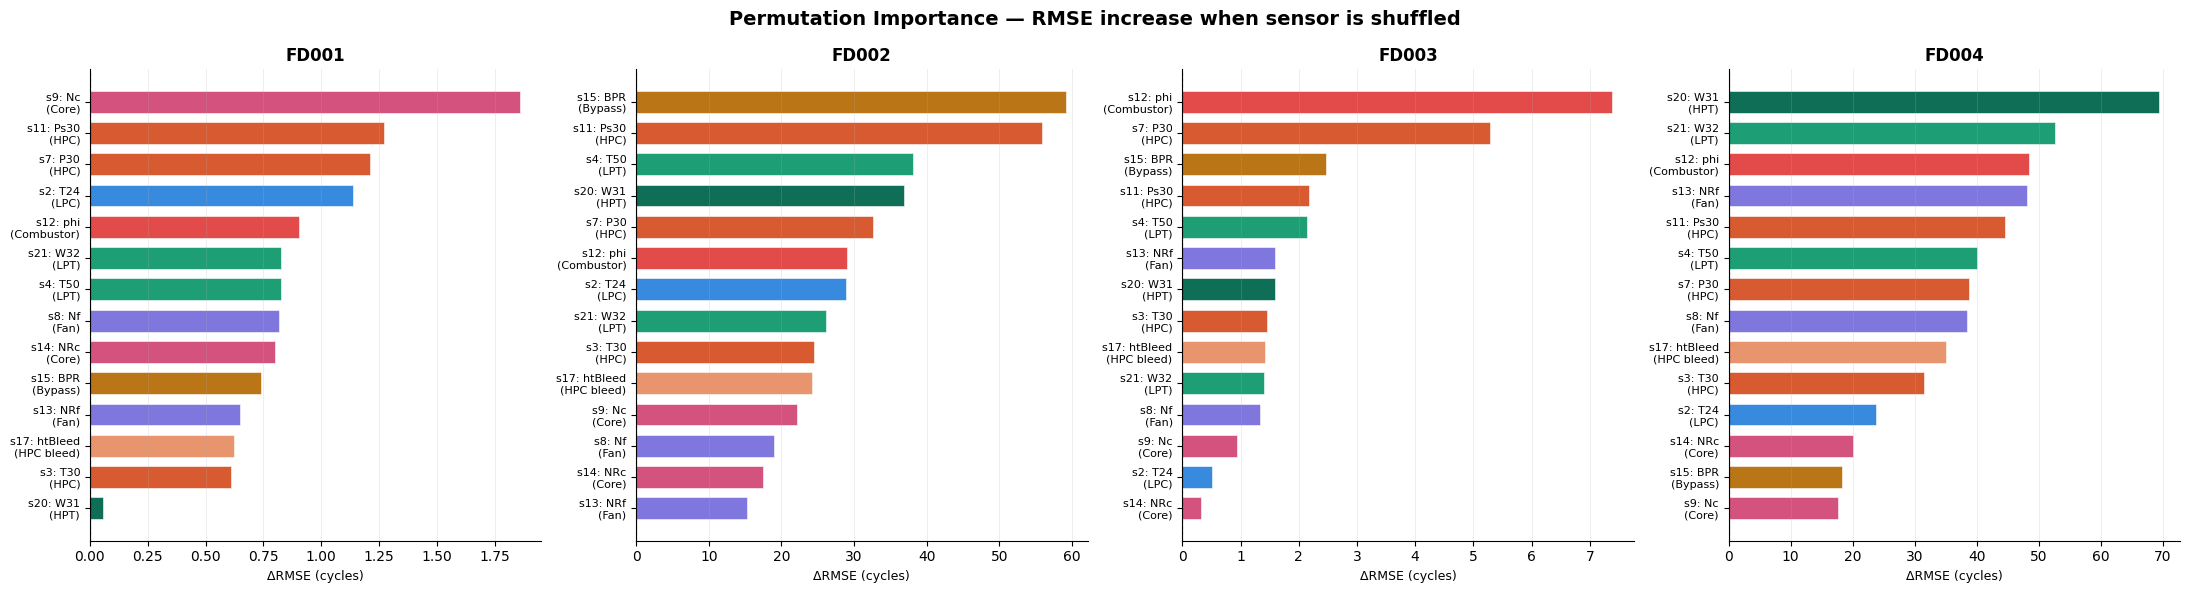

✅ Saved: /content/perm_importance.png

📊 Spearman rank correlation — SHAP vs Permutation importance:
  Subset          ρ      p-value Agreement
  -------- -------- ------------ ---------------
  FD001      0.5253       0.0537 Moderate ⚠️
  FD002      0.5780       0.0304 Moderate ⚠️
  FD003      0.7275       0.0032 Strong ✅
  FD004      0.6615       0.0100 Moderate ⚠️


In [ ]:
# ============================================================
# CELL 9: Permutation Importance Plots + SHAP vs Perm Rank Comparison
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("Permutation Importance — RMSE increase when sensor is shuffled",
             fontsize=14, fontweight="bold")

for col, subset in enumerate(SUBSETS):
    delta = perm_results[subset]
    ranked = np.argsort(delta)[::-1]
    colors_ranked = [SENSOR_COLORS[int(i)] for i in ranked]
    labels_ranked = [SENSOR_LABELS[int(i)] for i in ranked]

    ax = axes[col]
    ax.barh(range(14), delta[ranked], color=colors_ranked,
            edgecolor="white", linewidth=0.4, height=0.7)
    ax.set_yticks(range(14))
    ax.set_yticklabels(labels_ranked, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("ΔRMSE (cycles)", fontsize=9)
    ax.set_title(subset, fontweight="bold", fontsize=12)
    ax.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/perm_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: /content/perm_importance.png")

# ── Rank correlation: SHAP vs Permutation ──
print("\n📊 Spearman rank correlation — SHAP vs Permutation importance:")
print(f"  {'Subset':<8} {'ρ':>8} {'p-value':>12} {'Agreement'}")
print(f"  {'-'*8} {'-'*8} {'-'*12} {'-'*15}")
for subset in SUBSETS:
    shap_rank = all_shap_vals[subset].mean(axis=0)
    perm_rank = perm_results[subset]
    rho, pval = spearmanr(shap_rank, perm_rank)
    agreement = "Strong ✅" if rho > 0.7 else ("Moderate ⚠️" if rho > 0.4 else "Weak ❌")
    print(f"  {subset:<8} {rho:>8.4f} {pval:>12.4f} {agreement}")



  Computing temporal SHAP — FD001
  ✅ Loaded: /content/dualmixer_FD001.pt
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
    Raw shape: (200, 30, 14, 1)
    Final shape: (200, 30, 14)
    ✅ FD001 done

  Computing temporal SHAP — FD002
  ✅ Loaded: /content/dualmixer_FD002.pt
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 150 230  43 222 142 164 100  25 228
 181 203  82 173  44 226  69 243 252   9 202 104 259 258  62 218]
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 150 230  43 222 142 164 100  25 228
 181 203  82 173  44 226  69 243 252   9 202 104 259 258  62 218]
    Raw shape: (200, 30, 14, 1)
    Final shape: (200, 30, 14)
    ✅ FD002 done

  Computing temporal SHAP — FD003
  ✅ Loaded: /content/dualmixer_FD003.pt
val_index:[57 13 69 83 67 92 45 4

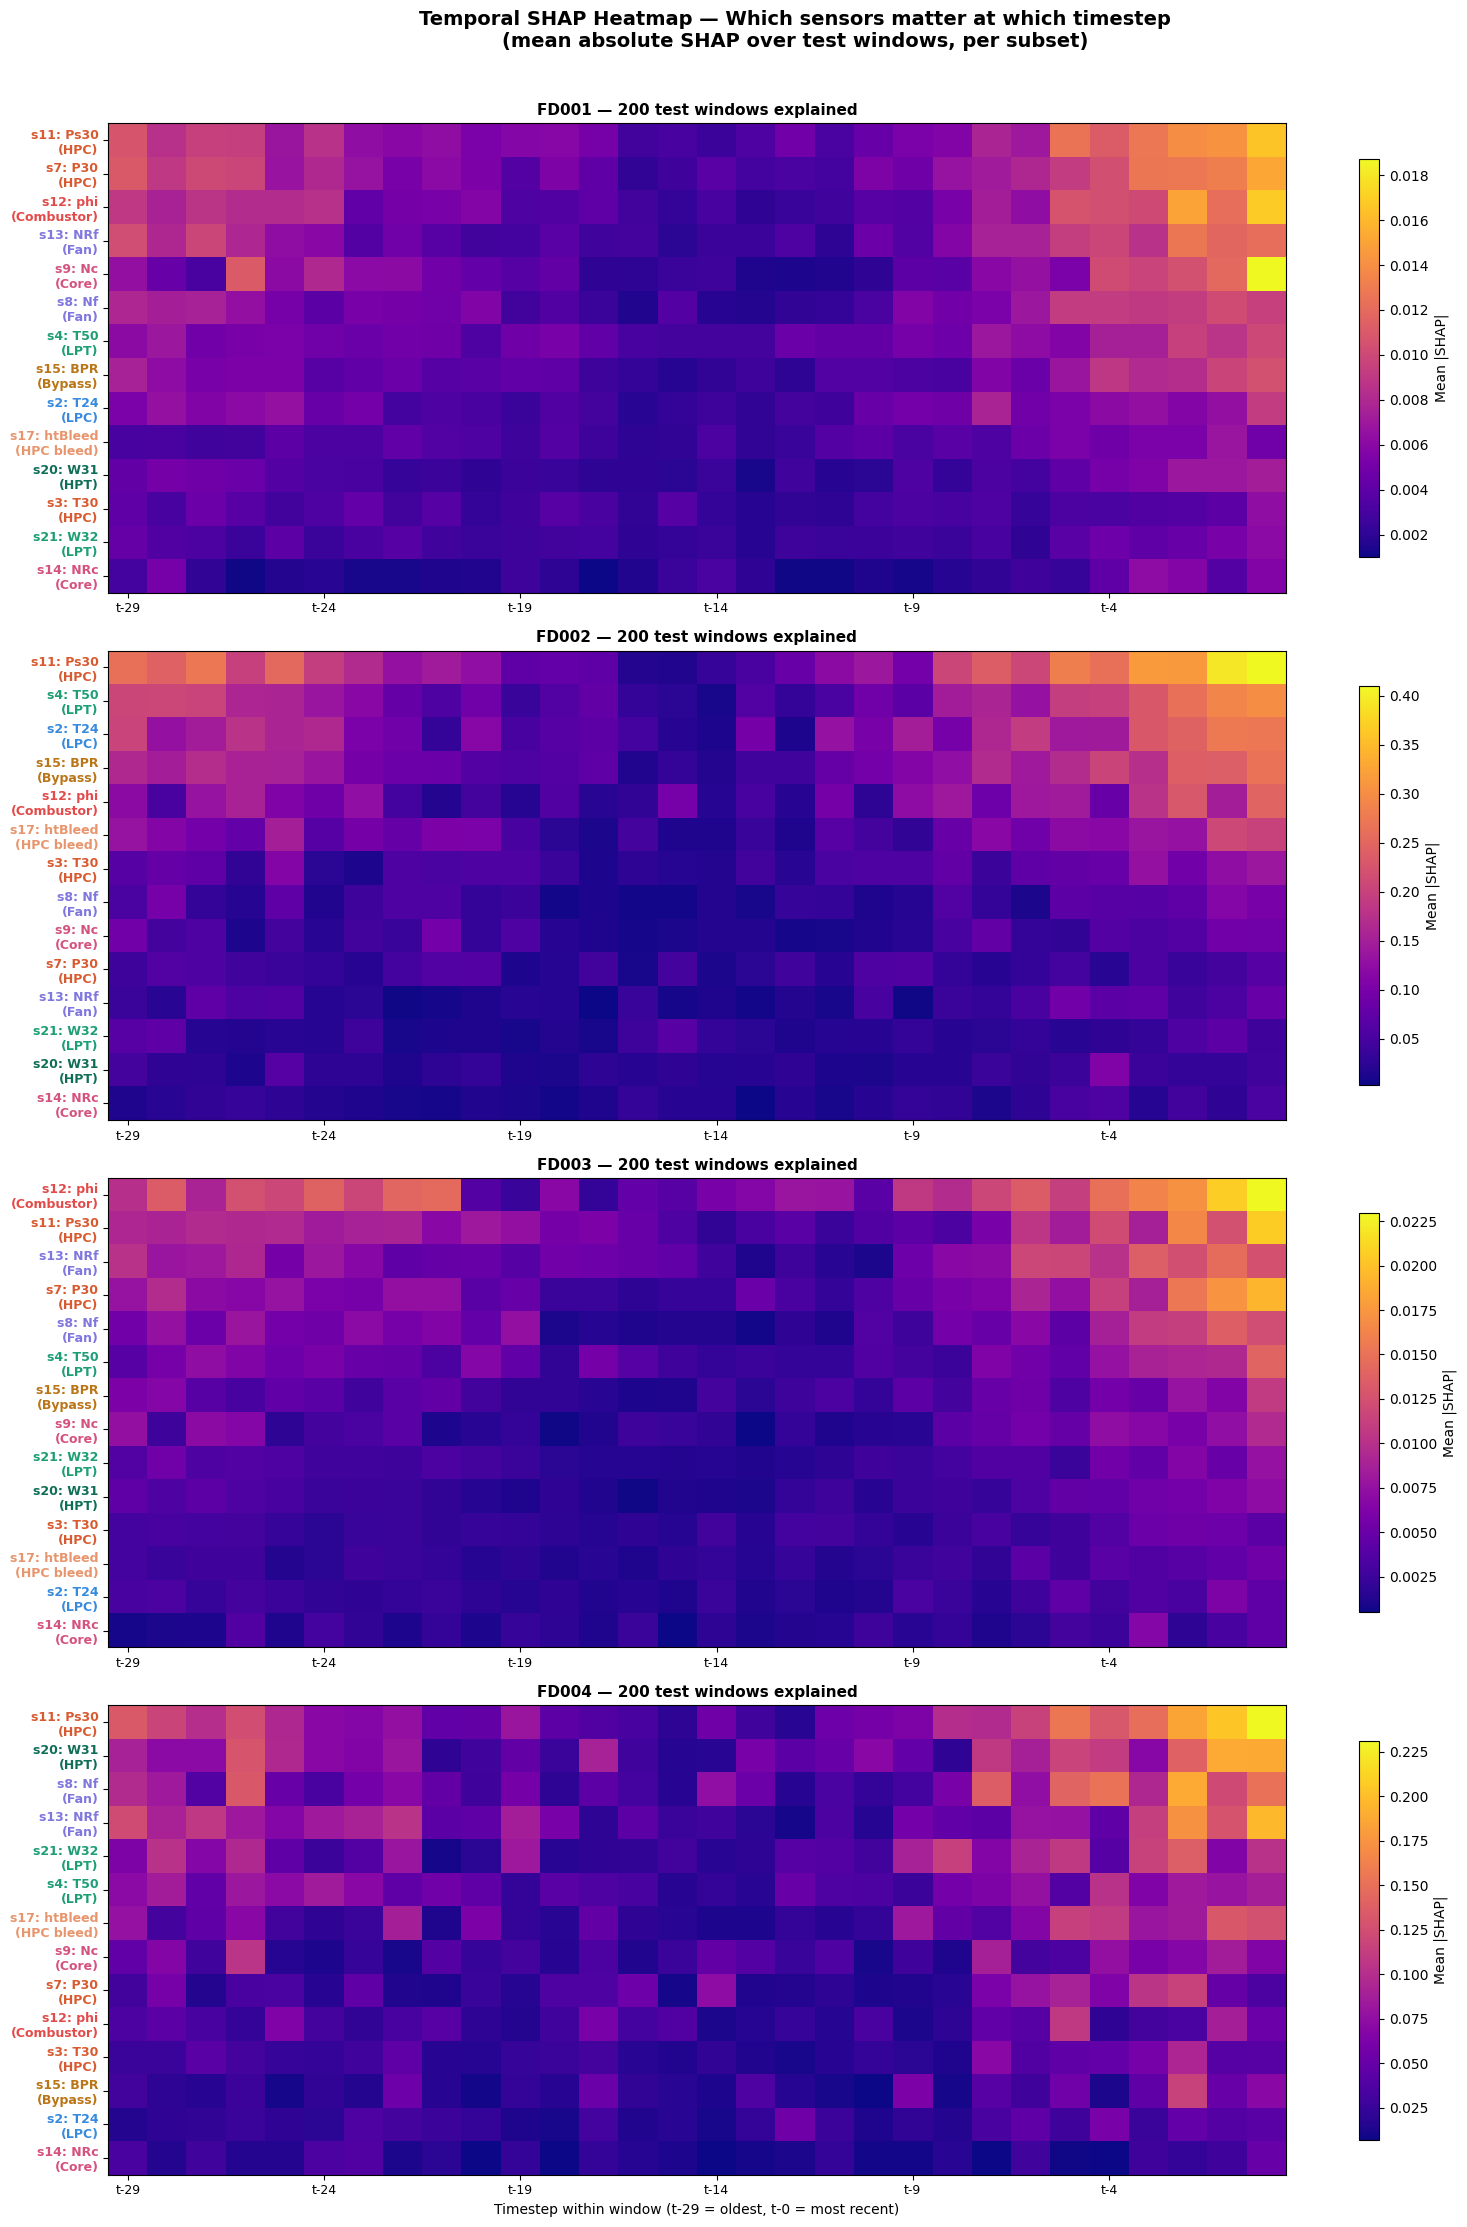


✅ Saved: /content/shap_temporal_heatmap_all.png


In [ ]:
# ============================================================
# CELL 10: Temporal SHAP Heatmap — All 4 Subsets
# ============================================================
# For each subset, compute mean |SHAP| per (timestep, sensor)
# across explained windows → heatmap (30 timesteps × 14 sensors)
# Shows whether the model focuses on recent vs older cycles.

import matplotlib.pyplot as plt
import numpy as np

N_BG  = 100   # background samples
N_EXP = 200   # test windows to explain

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("Temporal SHAP Heatmap — Which sensors matter at which timestep\n"
             "(mean absolute SHAP over test windows, per subset)",
             fontsize=14, fontweight="bold", y=1.01)

for row, SUBSET in enumerate(SUBSETS):
    print(f"\n  Computing temporal SHAP — {SUBSET}")

    model  = load_model(SUBSET)
    model.to(DEVICE)

    X_train = get_train_windows(SUBSET).to(DEVICE)
    X_test, y_test, ids_test = get_test_windows(SUBSET)
    X_test  = X_test.to(DEVICE)

    bg_idx     = torch.randperm(len(X_train))[:N_BG]
    background = X_train[bg_idx]
    te_idx     = torch.randperm(len(X_test))[:min(N_EXP, len(X_test))]
    X_exp      = X_test[te_idx]

    explainer = shap.GradientExplainer(model, background)
    sv = explainer.shap_values(X_exp)

    # Robust unwrapping
    if isinstance(sv, list): sv = sv[0]
    if isinstance(sv, list): sv = sv[0]
    sv = np.array(sv)
    print(f"    Raw shape: {sv.shape}")

    # Squeeze trailing size-1 output dim: (N,30,14,1) → (N,30,14)
    while sv.ndim > 3 and sv.shape[-1] == 1:
        sv = sv[..., 0]
    # Squeeze leading size-1 dims
    while sv.ndim > 3 and sv.shape[0] == 1:
        sv = sv[0]
    # Fix transposed axes: (N,14,30) → (N,30,14)
    if sv.ndim == 3 and sv.shape[1] == 14 and sv.shape[2] == 30:
        sv = sv.transpose(0, 2, 1)
    # Single-sample edge case
    if sv.ndim == 2:
        sv = sv[np.newaxis, ...]

    print(f"    Final shape: {sv.shape}")
    assert sv.ndim == 3 and sv.shape[1] == 30 and sv.shape[2] == 14, \
        f"Unexpected shape: {sv.shape}"

    # Mean absolute SHAP per (timestep, sensor) → (30, 14)
    temporal_imp = np.mean(np.abs(sv), axis=0).astype(float)

    # Rank sensors by overall importance for y-axis ordering
    sensor_order = np.argsort(temporal_imp.mean(axis=0))[::-1].tolist()

    # plot_data shape: (14, 30) — sensors on y, timesteps on x
    plot_data = temporal_imp[:, sensor_order].T

    ax = axes[row]
    im = ax.imshow(plot_data, aspect="auto", cmap="plasma", interpolation="nearest")

    ax.set_xticks(range(0, 30, 5))
    ax.set_xticklabels([f"t-{29-i}" for i in range(0, 30, 5)], fontsize=9)
    if row == 3:
        ax.set_xlabel("Timestep within window (t-29 = oldest, t-0 = most recent)",
                      fontsize=10)

    ax.set_yticks(range(14))
    ax.set_yticklabels([SENSOR_LABELS[i] for i in sensor_order], fontsize=9)
    for ytick, idx in zip(ax.get_yticklabels(), sensor_order):
        ytick.set_color(SENSOR_COLORS[idx])
        ytick.set_fontweight("bold")

    plt.colorbar(im, ax=ax, label="Mean |SHAP|", shrink=0.85)
    ax.set_title(f"{SUBSET} — {len(X_exp)} test windows explained",
                 fontweight="bold", fontsize=11)

    print(f"    ✅ {SUBSET} done")

plt.tight_layout()
plt.savefig("/content/shap_temporal_heatmap_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Saved: /content/shap_temporal_heatmap_all.png")


In [ ]:
# ============================================================
# CELL 11: Save Summary CSV + Download All XAI Outputs
# ============================================================
import pandas as pd
import numpy as np
import os

# Build summary table: sensor × subset SHAP + permutation importance
rows = []
for i, (k, v) in enumerate(KEPT_SENSORS):
    row = {
        "sensor_id":   k,
        "symbol":      v[0],
        "description": v[1],
        "zone":        v[2],
    }
    for subset in SUBSETS:
        row[f"SHAP_mean_{subset}"]  = round(float(all_shap_vals[subset][:, i].mean()), 6)
        row[f"SHAP_rank_{subset}"]  = int(
            np.argsort(all_shap_vals[subset].mean(axis=0))[::-1].tolist().index(i) + 1
        )
        row[f"Perm_ΔRMSE_{subset}"] = round(float(perm_results[subset][i]), 4)
        row[f"Perm_rank_{subset}"]  = int(
            np.argsort(perm_results[subset])[::-1].tolist().index(i) + 1
        )
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_csv("/content/xai_sensor_importance_summary.csv", index=False)
print("✅ Summary CSV saved: /content/xai_sensor_importance_summary.csv")
print()
print(df_summary[["symbol","zone"] +
                  [f"SHAP_rank_{s}" for s in SUBSETS] +
                  [f"Perm_rank_{s}" for s in SUBSETS]].to_string(index=False))

# Download all outputs
try:
    from google.colab import files
    outputs = [
        "/content/shap_global_bar_beeswarm.png",
        "/content/shap_crosssubset_heatmap.png",
        "/content/shap_local_waterfall.png",
        "/content/perm_importance.png",
        "/content/shap_temporal_heatmap.png",
        "/content/shap_temporal_heatmap_all.png",
        "/content/xai_sensor_importance_summary.csv",
    ]
    for f in outputs:
        if os.path.exists(f):
            files.download(f)
            print(f"📥 Downloaded: {f}")
except ImportError:
    print("ℹ️  Not in Colab — files saved at /content/")


✅ Summary CSV saved: /content/xai_sensor_importance_summary.csv

 symbol      zone  SHAP_rank_FD001  SHAP_rank_FD002  SHAP_rank_FD003  SHAP_rank_FD004  Perm_rank_FD001  Perm_rank_FD002  Perm_rank_FD003  Perm_rank_FD004
    T24       LPC                9                3               13               13                4                7               13               11
    T30       HPC               12                7               11               11               13                9                8               10
    T50       LPT                5                2                6                6                7                3                5                6
    P30       HPC                2               10                3                9                3                5                2                7
     Nf       Fan                6                8                5                3                8               12               11                8
     Nc    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: /content/shap_global_bar_beeswarm.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 Downloaded: /content/shap_temporal_heatmap_all.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloaded: /content/xai_sensor_importance_summary.csv
